In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import pingouin as pg
import matplotlib.pyplot as plt
import matplotlib

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.6f}'.format

matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 


df = pd.read_csv("participants_info.csv", delimiter=",")
df_mod = pd.read_csv("modalities_info.csv", delimiter=",")[["participant_id", "session", "anat", "fmri", "dwi"]].drop_duplicates(subset="participant_id", keep="first")
df = pd.merge(df, df_mod, on = "participant_id", how="left")
# Assume df is your dataframe

# 2. Map group codes to labels
group_map = {
    0: "HC",
    0.1: "HC Sibling",
    1: "SCHZ",
    1.1: "SCHZ Sibling",
    2: "BD",
    3: "FEP",
    4: "MDD",
    5: "CHR",
    6: "ADHD",
    7: "PTSD",
    8: "GAD",
    9: "SAD",
    10: "SUD",
    11: "OCD",
    12: "SEAD",
    13: "ASD",
    14: "CPS",
    15: "Stroke",
    16: "BPD",
    17: "ARMS",
    18: "AN",
    19: "WR",
    20: "AUD",
    21: "Panic Episode",
    22: "Agoraphobia"
}

# Keep only one row per participant
df_unique = df.copy()

# Split ONLY entries that contain ';'
df_unique["group_split"] = df_unique["group"].astype(str).str.split(";")

# Expand multiple-group participants into multiple rows
df_exploded = df_unique.explode("group_split")

# Convert to numeric (preserves 0.1, 1.1, etc.)
df_exploded["group_split"] = pd.to_numeric(
    df_exploded["group_split"].str.strip(),
    errors="coerce"
)

# Map codes to labels
df_exploded["group_label"] = df_exploded["group_split"].map(group_map)

# Count participants in each group
counts = df_exploded["group_label"].value_counts()

# Percentage relative to total unique participants
n_participants = df_unique["participant_id"].nunique()

percentages = counts / n_participants * 100

result = pd.DataFrame({
    "count": counts,
    "percentage": percentages
}).sort_values("count", ascending=False)

print(result)

               count  percentage
group_label                     
HC              4878   57.213230
SCHZ            1147   13.452967
MDD              786    9.218860
ADHD             322    3.776683
GAD              246    2.885292
BD               243    2.850106
ASD              127    1.489561
SUD              125    1.466104
HC Sibling        87    1.020408
CHR               81    0.950035
SCHZ Sibling      79    0.926578
CPS               67    0.785832
WR                58    0.680272
AN                58    0.680272
ARMS              52    0.609899
PTSD              49    0.574713
Panic Episode     47    0.551255
BPD               46    0.539526
FEP               41    0.480882
AUD               41    0.480882
SAD               31    0.363594
OCD               27    0.316678
Agoraphobia       18    0.211119
Stroke            10    0.117288
SEAD               1    0.011729


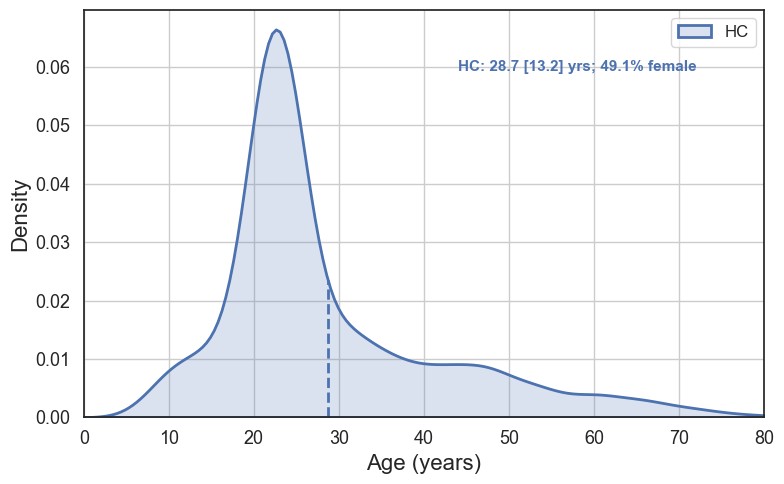

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde


sns.set(style="white")

# -----------------------------
# IDENTIFY HC PARTICIPANTS
# -----------------------------
hc_ids = (
    df_exploded.loc[df_exploded["group_label"] == "HC", "participant_id"]
    .dropna()
    .unique()
)

# -----------------------------
# KEEP ONE ROW PER HC PARTICIPANT
# -----------------------------
df_hc = df_unique[df_unique["participant_id"].isin(hc_ids)].copy()

# -----------------------------
# SEX MAP
# -----------------------------
sex_map = {0: "Female", 1: "Male"}

# -----------------------------
# PLOT
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

color = "#4C72B0"

ages = pd.to_numeric(df_hc["age"], errors="coerce").dropna()

if len(ages) > 1:
    sns.kdeplot(
        ages,
        fill=True,
        linewidth=2,
        color=color,
        label="HC",
        alpha=0.2,
        ax=ax
    )

    mean_age = ages.mean()
    kde = gaussian_kde(ages)
    y_mean = kde(mean_age)[0]

    ax.plot(
        [mean_age, mean_age],
        [0, y_mean],
        color=color,
        linestyle="--",
        linewidth=2
    )

    std_age = ages.std()

    sex_clean = pd.to_numeric(df_hc["sex"], errors="coerce")
    sex = sex_clean.map(sex_map).dropna()

    sex_pct = sex.value_counts(normalize=True) * 100
    female_pct = sex_pct.get("Female", 0)

    stats_text = (
        f"HC: {mean_age:.1f} [{std_age:.1f}] yrs; "
        f"{female_pct:.1f}% female"
    )

    ax.set_xlabel("Age (years)", fontsize=16)
    ax.set_ylabel("Density", fontsize=16)

    ax.set_xticks(np.arange(0, 81, 10))
    ax.set_xlim(0, 80)

    ax.legend(fontsize=12)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    ax.grid(True)

    ax.text(
        0.55, 0.85,
        stats_text,
        transform=ax.transAxes,
        fontsize=11,
        color=color,
        fontweight="bold"
    )

else:
    print("Not enough HC participants with valid age values to plot.")

plt.tight_layout()
plt.savefig("fig1.pdf", format="pdf", bbox_inches="tight")
plt.show()

C:\Users\k2371000\AppData\Local\Temp\ipykernel_19404\1460513437.py:14: DtypeWarning: Columns (9,44,54,181,275,276) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("metafile.csv", delimiter=",")


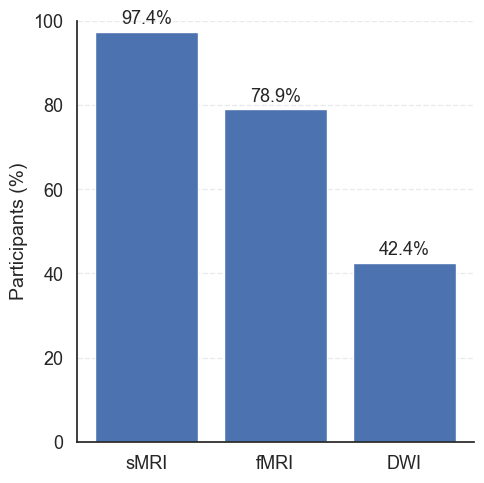

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# SETTINGS
# -----------------------------
sns.set(style="white")

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("metafile.csv", delimiter=",")

# -----------------------------
# ONE ROW PER PARTICIPANT
# -----------------------------
df_unique = (
    df.sort_values("session")
      .drop_duplicates(subset="participant_id", keep="first")
)

# -----------------------------
# MAP GROUPS
# -----------------------------
group_map = {
    0: "HC", 0.1: "HC Sibling",
    1: "SCHZ", 1.1: "SCHZ Sibling",
    2: "BD", 3: "FEP", 4: "MDD",
    5: "CHR", 6: "ADHD", 7: "PTSD",
    8: "GAD", 9: "SAD", 10: "SUD",
    11: "OCD", 12: "SEAD", 13: "ASD",
    14: "CPS", 15: "Stroke", 16: "BPD",
    17: "ARMS"
}

df_unique["group_label"] = df_unique["group"].map(group_map)

# -----------------------------
# KEEP ONLY HC
# -----------------------------
df_hc = df_unique[df_unique["group_label"] == "HC"].copy()

# -----------------------------
# MODALITIES
# -----------------------------
modalities = ["anat", "fmri", "dwi"]
labels = ["sMRI", "fMRI", "DWI"]

# -----------------------------
# COMPUTE %
# -----------------------------
values = [df_hc[col].mean() * 100 for col in modalities]

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(5, 5))
plt.grid(axis='y', linestyle='--', alpha=0.4)

color = "#4C72B0"  # single colour

plt.bar(
    labels,
    values,
    color=color
)

# -----------------------------
# LABELS
# -----------------------------
for i, val in enumerate(values):
    plt.text(
        i,
        val + 1,
        f"{val:.1f}%",
        ha='center',
        va='bottom',
        fontsize=13
    )

# -----------------------------
# STYLING
# -----------------------------
plt.ylabel("Participants (%)", fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.ylim(0, 100)

sns.despine()

plt.tight_layout()
plt.savefig('fig2.pdf', format='pdf', bbox_inches='tight')
plt.show()